### Формирование модели машинного обучения

В текущей работе рассматривается анализ датасета [California Housing](https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv).

В работе рассматривается:
1. обучение регрессионной модели для прогнозирования **цен домов в Калифорнии** на основе различных характеристик района (количество комнат, население, доход и т.д.);
2. сохранение обученной модели в виде **конвейера обработки данных (Pipeline)** для последующего использования в веб-сервисе инференса.

In [1]:
import numpy as np
import pandas as pd
from seaborn import pairplot
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
#from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from pickle import dump
from pathlib import Path

In [2]:
data_path = "../data/housing.csv"

df = pd.read_csv(data_path, header=0)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Столбец "`total_bedrooms`" содержит что-то, кроме чисел. Выясним, что.

In [5]:
df["total_bedrooms"] = pd.to_numeric(df["total_bedrooms"], errors='coerce')
print("Пропуски в total_bedrooms:", df["total_bedrooms"].isna().sum())

Пропуски в total_bedrooms: 207


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df[df["total_bedrooms"].isna()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


Итак, столбец `total_bedrooms` содержит пропущенные значения.  
Мы будем обрабатывать их в Pipeline, заполняя медианой или средним значением.  
Все остальные признаки числовые и используются для обучения модели.

In [8]:
#df["horsepower"] = df["horsepower_floats"]
#df = df.drop("horsepower_floats", axis=1)
#df = df.drop("car name", axis=1)

In [9]:
#df.info()

In [10]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Посмотрим на распределение данных и взаимосвязи между признаками и целевой переменной `median_house_value`.
Это помогает понять, какие признаки могут сильно влиять на прогноз цен домов.

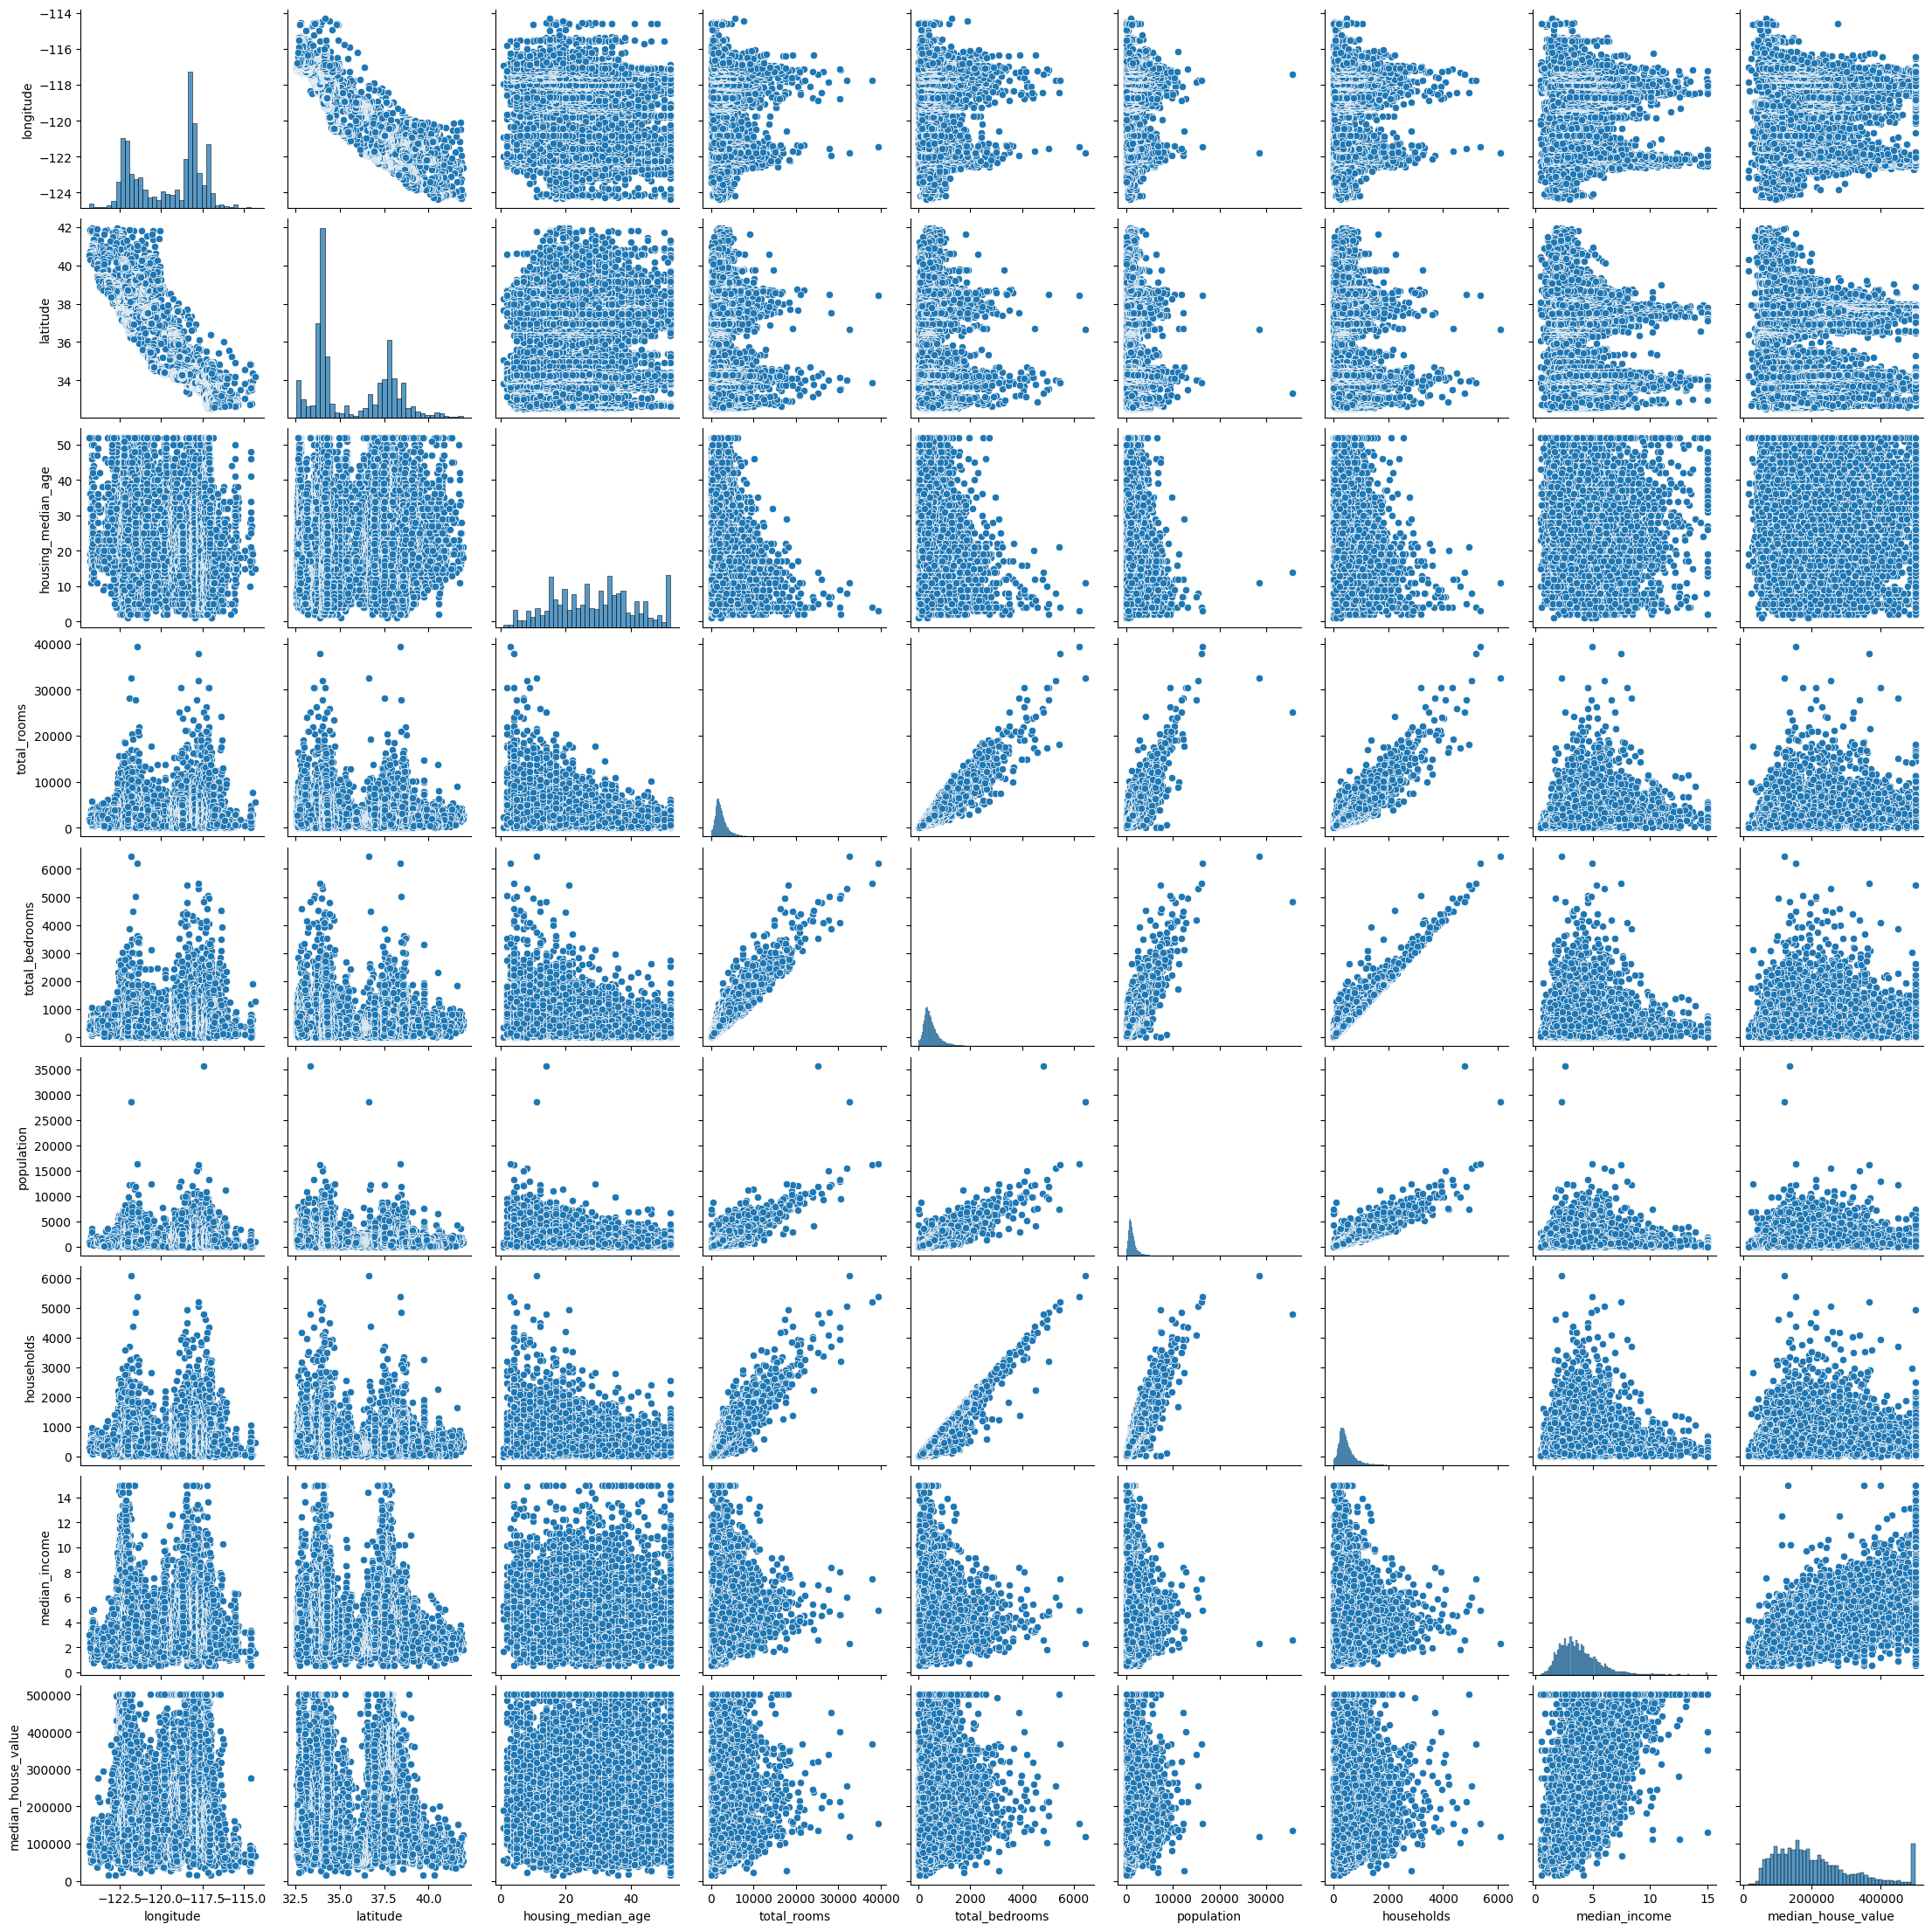

In [11]:
pairplot(df)

Посмторим на распределение категориальных переменных. В датасете их нет.

In [12]:
#df["cylinders"].value_counts()

In [13]:
#df["origin"].value_counts()

Выясним, содержатся ли выбросы в данных.

In [14]:
#df[["mpg", "displacement", "horsepower", "weight",
#    "acceleration", "model_year"]].boxplot(rot=45)

Сформируем конвейеры для обработки количественных и категориальных данных.

In [15]:
numeric_features = [
    "longitude", "latitude", "housing_median_age", "total_rooms",
    "total_bedrooms", "population", "households", "median_income"]
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), 
        ("scaler", StandardScaler()),
    ]
)

In [16]:
#categorical_features = ["cylinders", "origin"]
#categorical_transformer = Pipeline(
#    steps=[
#        ("onehot-encoder", OneHotEncoder(drop="first", 
#                                         handle_unknown="ignore")),
#    ]
#)

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        #("categorical", categorical_transformer, categorical_features),
    ]
)

In [18]:
regressor = RandomForestRegressor(
    n_estimators=100, 
    random_state=42
)
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor), 
        ("regressor", regressor)
    ]
)

In [19]:
X = df[numeric_features]
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (14448, 8)
X_test: (6192, 8)
y_train: (14448,)
y_test: (6192,)


In [20]:
# Признаки
X_train = X_train[numeric_features]
X_test = X_test[numeric_features]

# Целевая переменная
y_train = y_train
y_test = y_test

#Подберем коэффициент регуляризации для линейной регрессии.

In [21]:
#param_grid = {
#    "regressor__regressor__alpha": np.linspace(0.0, 3.0, num=31),
#}

Теперь мы должны подбирать гиперпараметры RandomForestRegressor.

In [22]:
param_grid = {
    "regressor__n_estimators": [50, 100],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_split": [2, 5],
}

In [23]:
search_cv = GridSearchCV(pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)

In [24]:
search_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [10, 20, None],
                         'regressor__min_samples_split': [2, 5],
                         'regressor__n_estimators': [50, 100]},
             scoring='r2')

In [25]:
print("Best params:")
print(search_cv.best_params_)

Best params:
{'regressor__max_depth': None, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}


In [26]:
search_cv.score(X_train, y_train)

0.961571706570194

In [27]:
search_cv.score(X_test, y_test)

0.811056603936537

Сохраним полученный конвейер обработки данных для дальнейшего использования.

In [28]:
Path("../models").mkdir(parents=True, exist_ok=True)

with open("../models/pipeline.pkl", "wb") as file:
    dump(search_cv, file)